decoding_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,decoded_position_object_id
2c17a7b1-9d7a-6fa1-1d8b-0979c0c5bec9,Lily20251217_.nwb,5,Lily20251217_XXN3TG1XDF.nwb,935d9096-30f1-4ba7-a858-138d138da42c


{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 5, 'block': 1}: HexmazeNoStim
saved figures/Lily20251217_epoch5_block1_decode.pdf


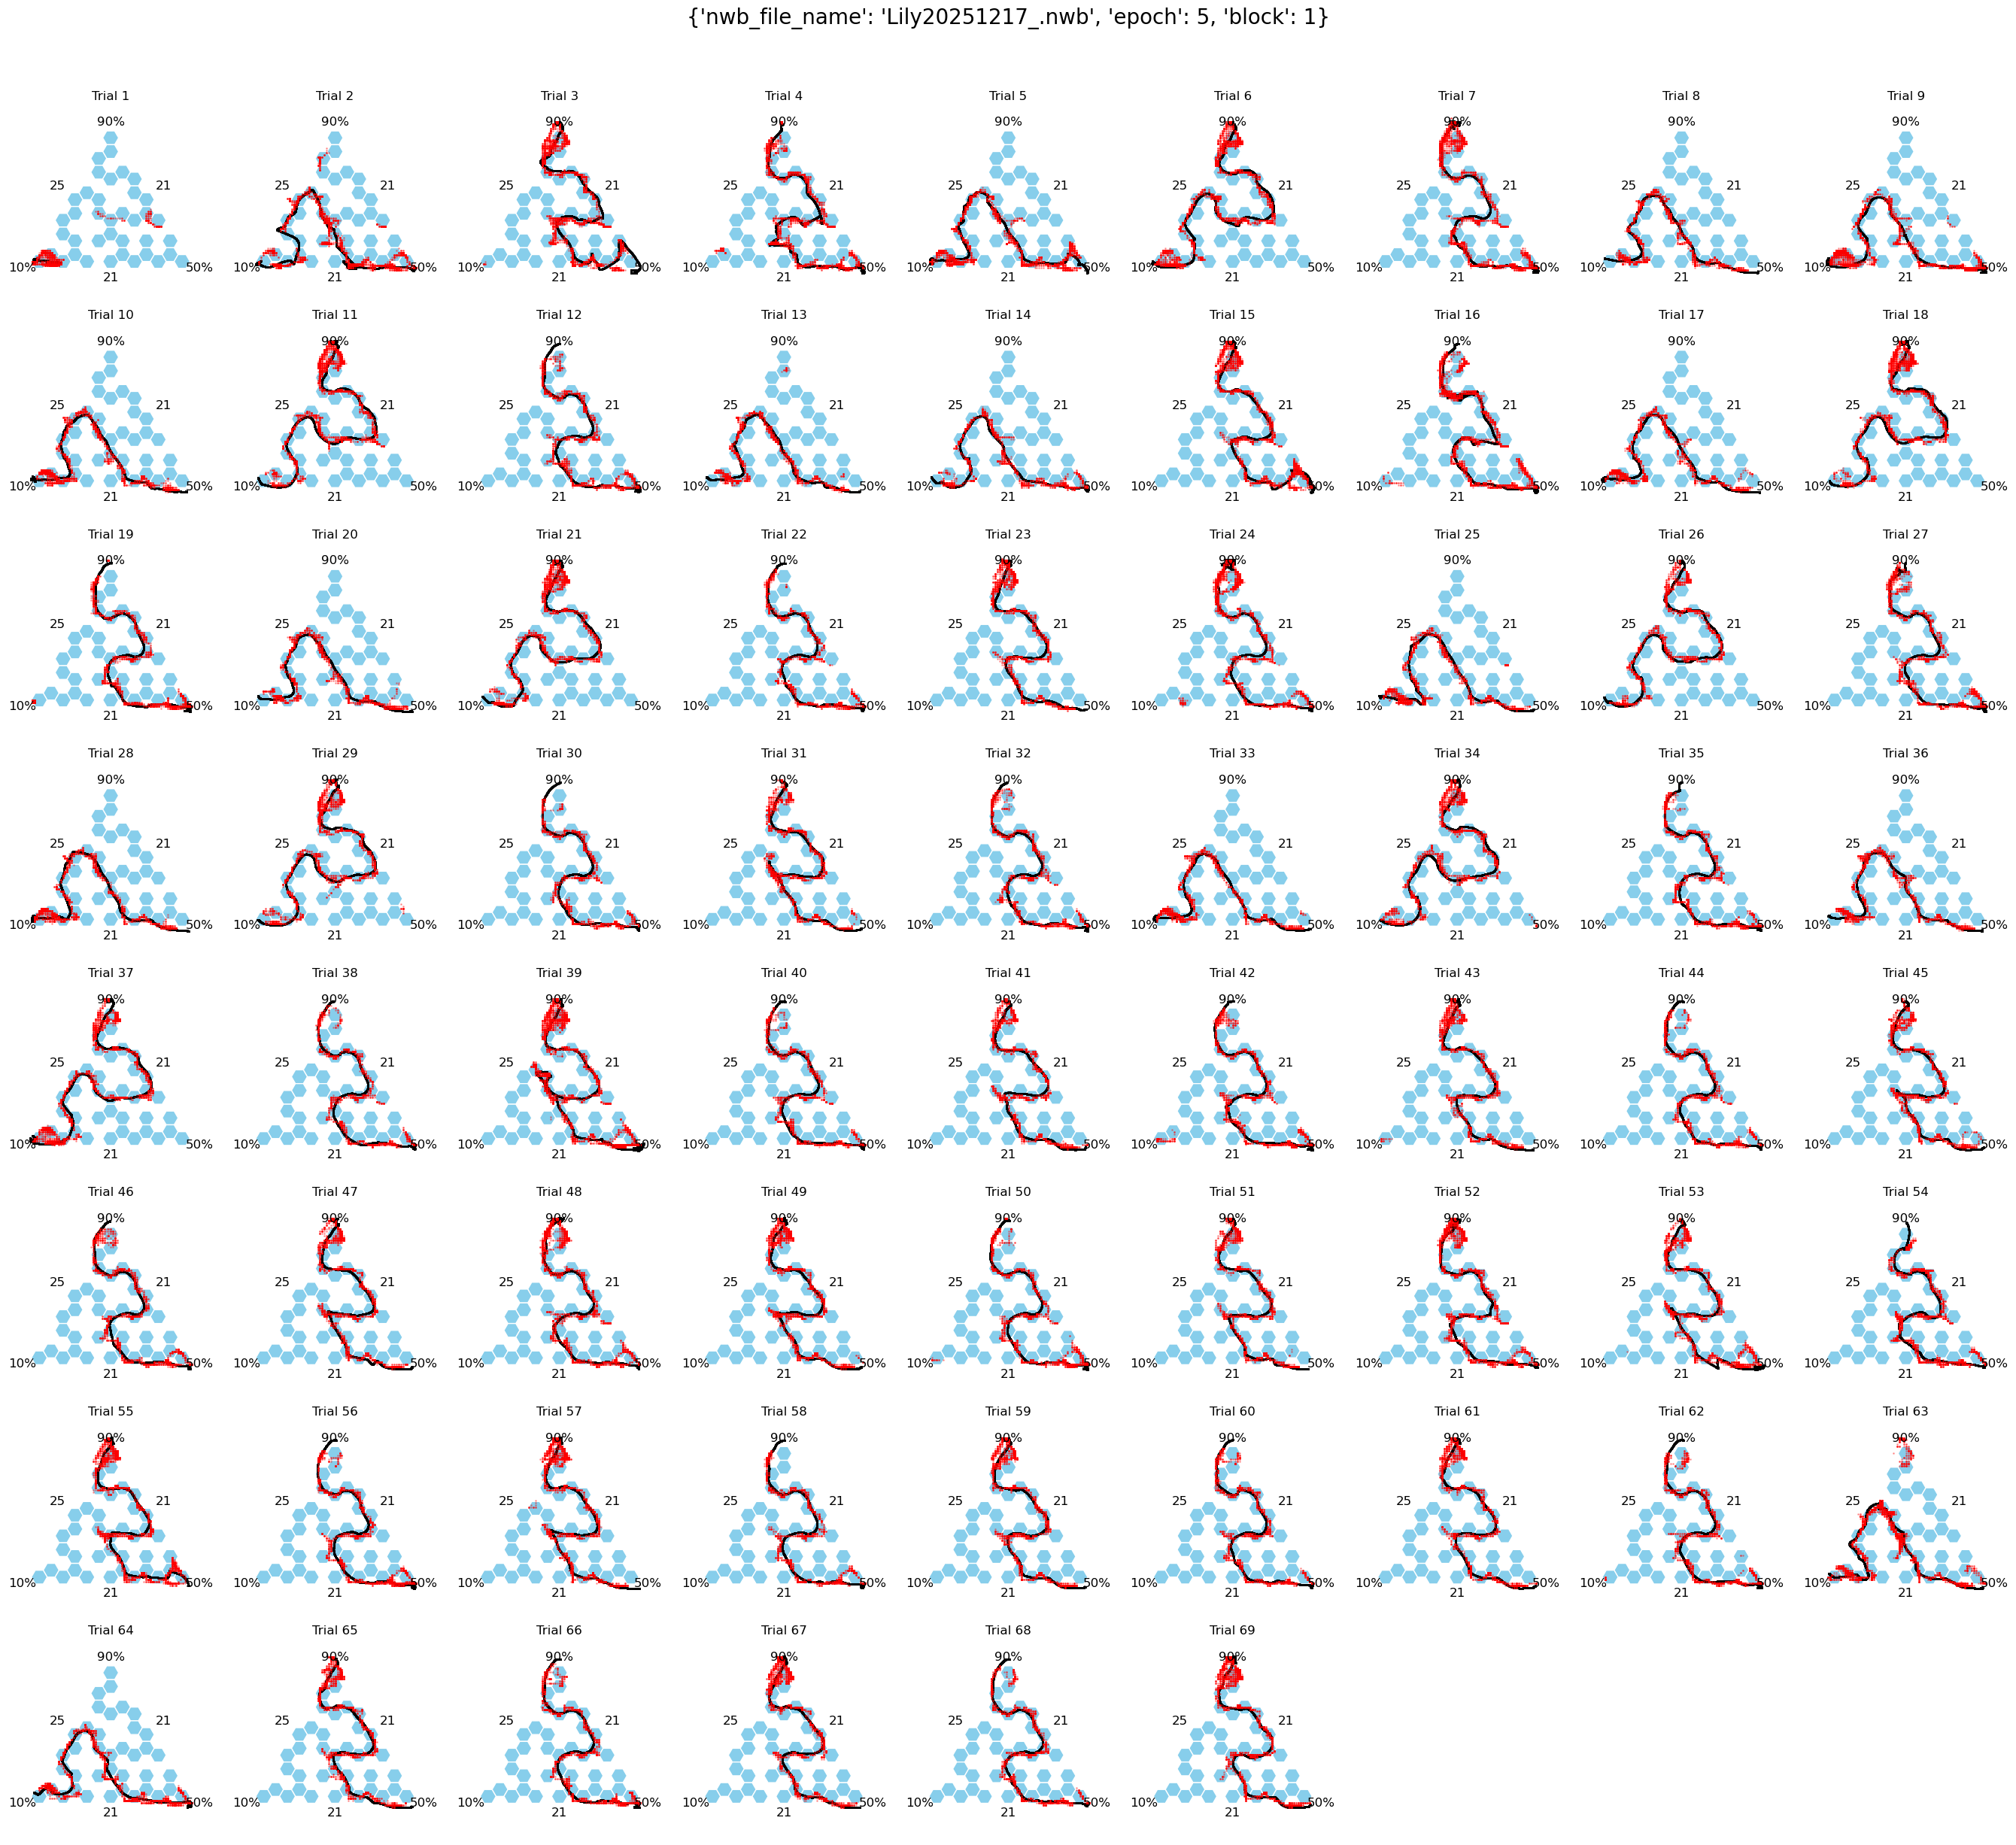

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 5, 'block': 2}: HexmazeNoStim


KeyboardInterrupt: 

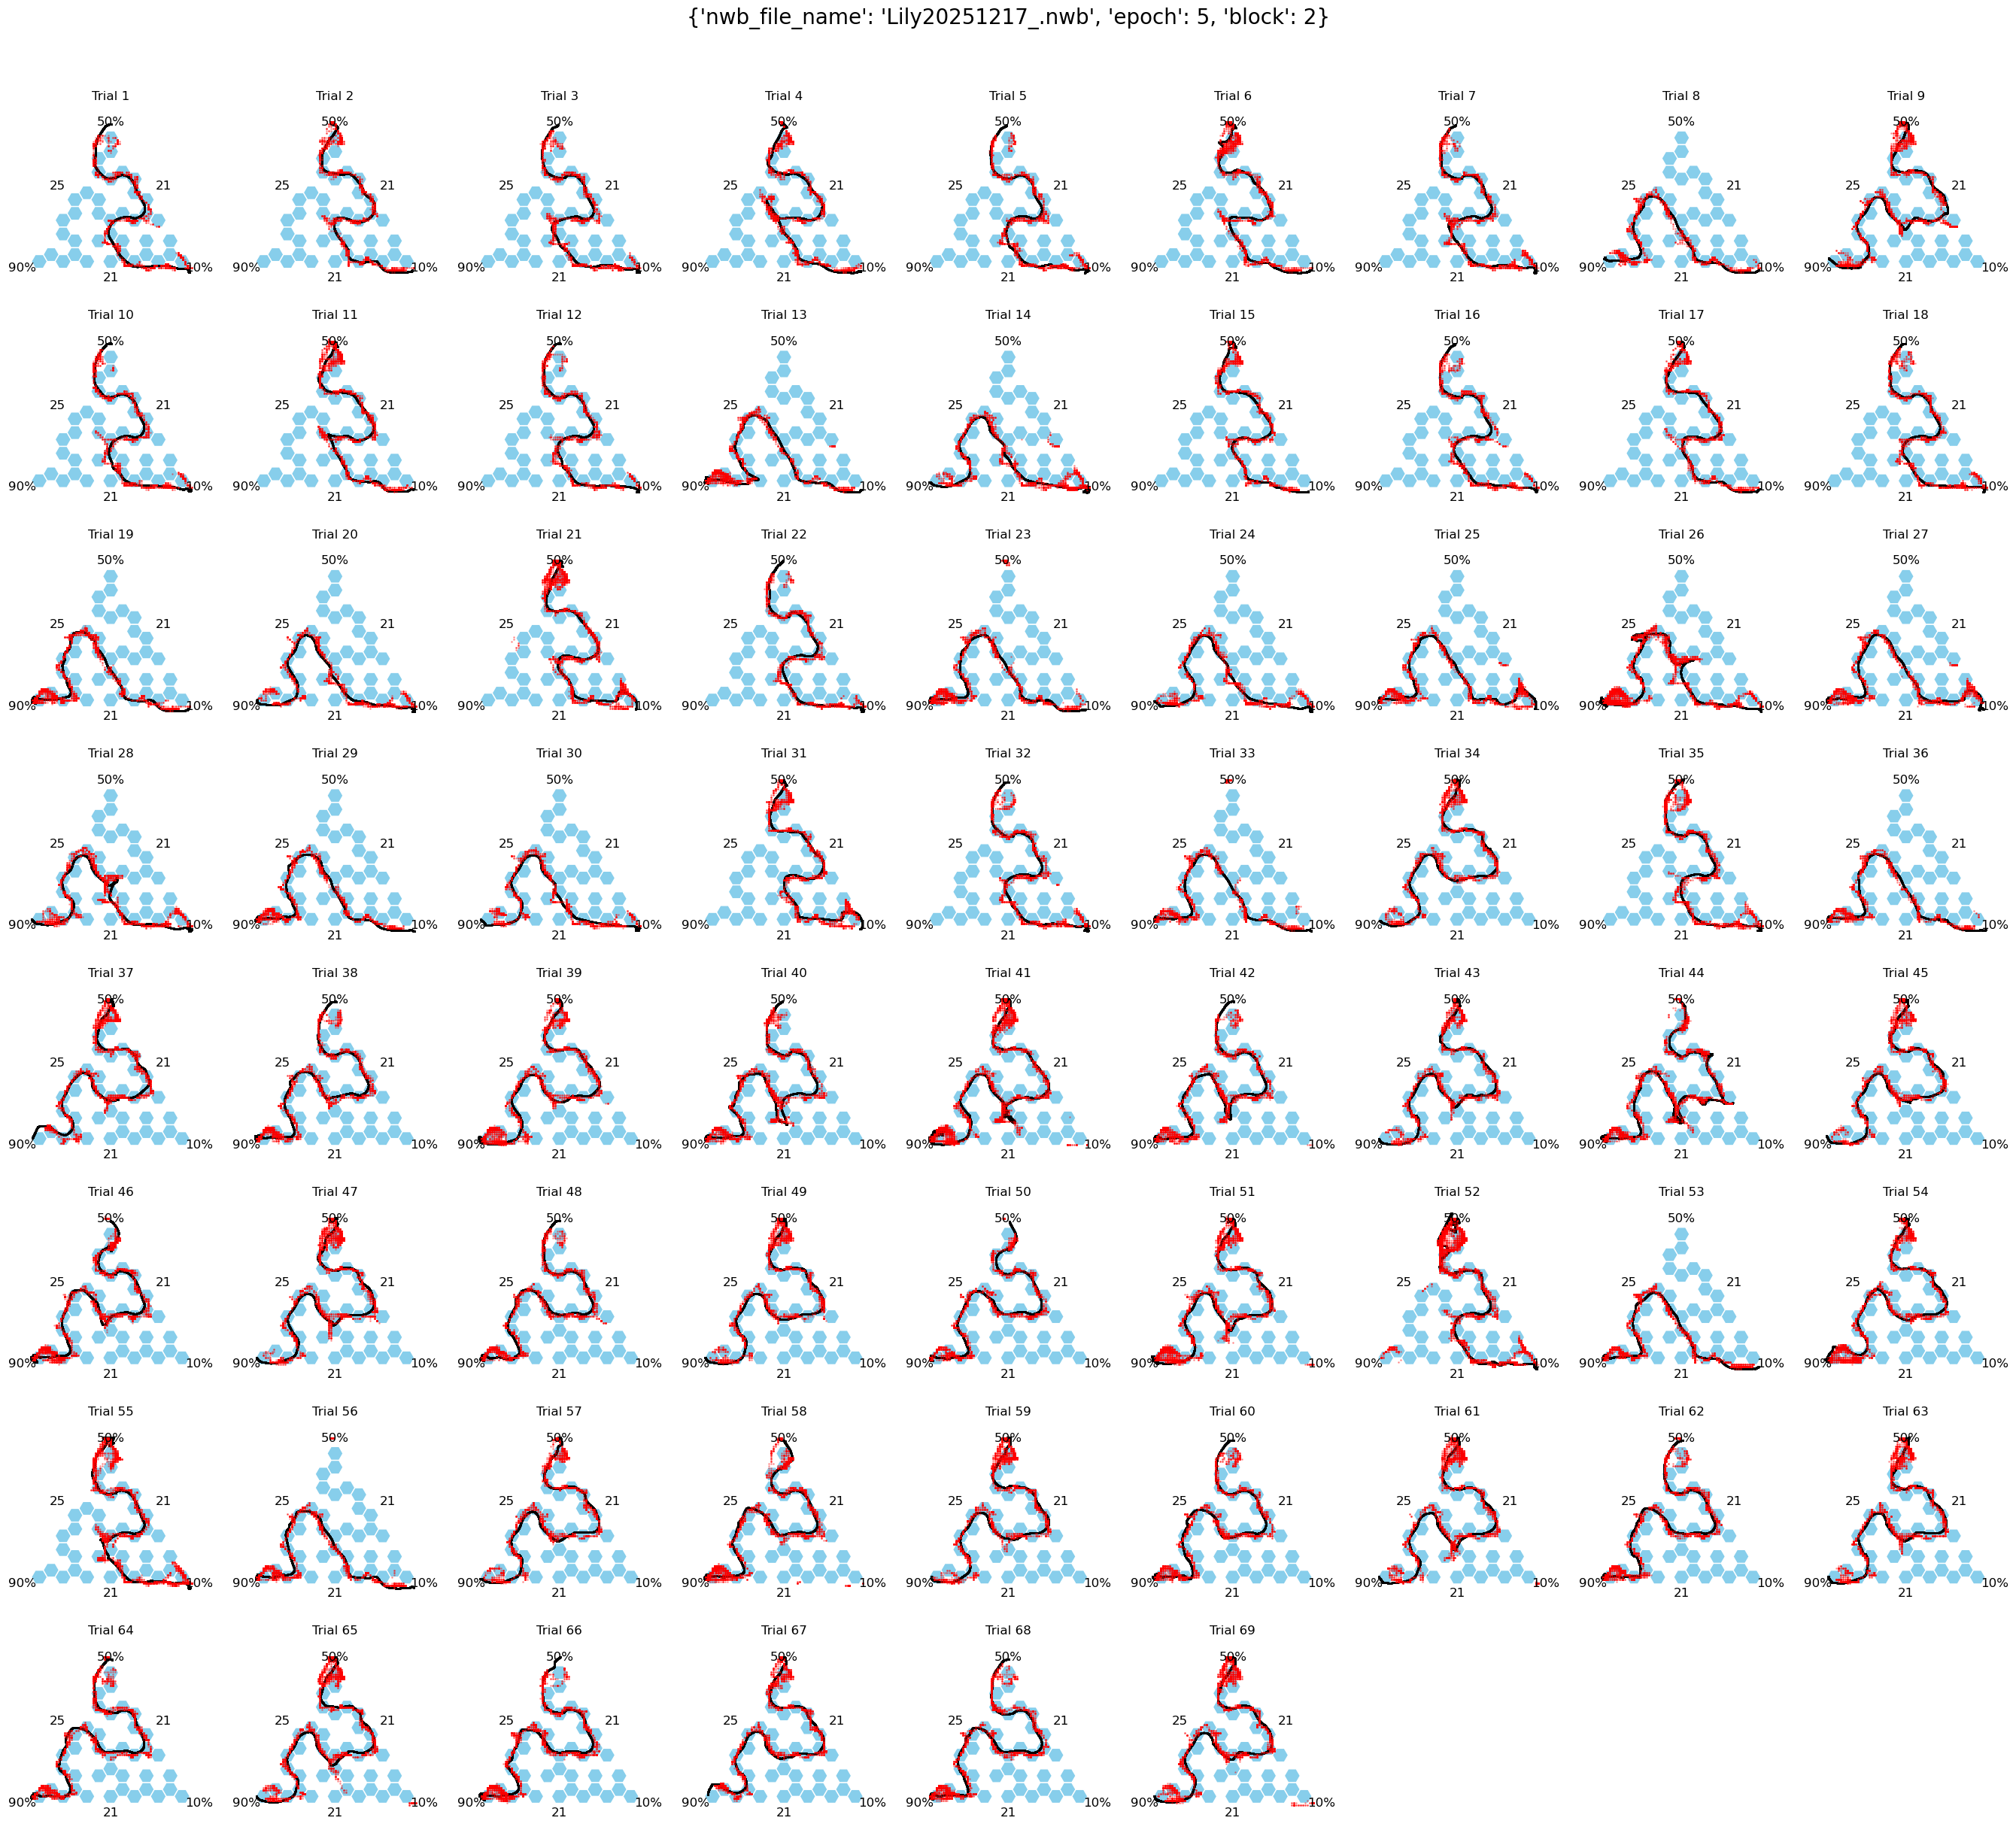

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hexmaze import plot_hex_maze

import spyglass.common as sgc
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock, HexCentroids
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition

restriction = {"nwb_file_name LIKE 'Lily20251217%'"}

# Get decode keys based on restriction
decode_keys = (HexMazeDecodedPosition() & restriction).fetch("KEY", order_by="nwb_file_name, epoch")
display(HexMazeDecodedPosition() & decode_keys)

# Only show decoded position if it meets these critera:
spatial_cov_threshold = 200 # 95% decode coverage must be less than this in cm2
speed_threshold = 2 # rat speed must be more than this in cm/s
decode_distance_threshold = 0 # decode distance from rat must be greater than this in cm

# Folder to save one PDF per block into
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Loop through blocks
for key in (HexMazeBlock() & decode_keys).fetch("KEY", order_by="nwb_file_name, epoch, block"):
    # Get block info
    print(f"{key}: {(sgc.Session() & key).fetch('session_description')[0]}")
    block = HexMazeBlock() & key
    trials = HexMazeBlock.Trial() & key
    num_trials = len(trials)
    maze, p_a, p_b, p_c = block.fetch1("config_id", "p_a", "p_b", "p_c")
    reward_probs = [int(p_a), int(p_b), int(p_c)]
    centroids = HexCentroids().get_core_hex_centroids_dict_cm(key)
    
    # Fetch actual and decoded position
    # (Note we would need to add decoding_merge_id to key if we have multiple entries for a nwb/epoch/block)
    pos_df = (HexMazeDecodedPosition() & key).fetch1_dataframe()
    
    # Set up square-ish grid for trials
    ncols = int(np.ceil(np.sqrt(num_trials)))
    nrows = int(np.ceil(num_trials / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))

    # Make sure axes is 1D so flatten doesn't break
    if isinstance(axes, plt.Axes):
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    # Big title
    fig.suptitle(f"{key}", fontsize=20, y=1.02)

    # Loop over trials
    for i, trial_info in enumerate(trials):
        # Get trial start/end
        start, end = (sgc.IntervalList() & trial_info).fetch1("valid_times")[0]
        df_trial = pos_df.loc[start:end]
        
        axes[i].set_title(f"Trial {i+1}")
        plot_hex_maze(
            ax=axes[i],
            barriers=maze,
            centroids=centroids,
            snap_centroids=True,
            invert_yaxis=True,
            show_barriers=False,
            show_hex_labels=False,
            show_stats=True,
            reward_probabilities=reward_probs,
        )
            
        # Plot actual position for this trial in black
        axes[i].scatter(df_trial["position_x"], df_trial["position_y"], s=1, color='k')
        # Filter decoded position based on our criteria
        pred = df_trial[
            (df_trial["spatial_cov"] < spatial_cov_threshold) &
            (df_trial["speed"] > speed_threshold) #&
           # (df_trial["decode_distance"] > decode_distance_threshold)
        ]
        # Plot decoded position for this trial in red
        axes[i].scatter(pred["decode_position_x"], pred["decode_position_y"], s=1, alpha=0.3, color="red")

    # Hide unused axes
    for j in range(num_trials, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    # Save this block's figure, named by nwb_file_name / epoch / block
    session_id = key["nwb_file_name"].replace("_.nwb", "")
    fig_path = FIG_DIR / f"{session_id}_epoch{key['epoch']}_block{key['block']}_decode.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    print(f"saved {fig_path}")

    plt.show()

In [5]:
import matplotlib; matplotlib.get_backend()

'module://matplotlib_inline.backend_inline'